In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Waste_by_site_of_generations";',
    engine
)
df

,Id,Year,Total,Households,Commercial_waste
0,1,2018,625386.0,509002.0,116384.0
1,2,2019,632484.0,522983.0,109500.0
2,3,2020,630086.0,522954.0,107132.0
3,4,2021,632087.0,528261.0,103826.0
4,5,2022,605638.0,506257.0,99381.0
5,6,2023,621686.0,507138.0,114547.0
6,7,2024,637471.0,535606.0,101865.0


In [3]:
df = df.drop(columns=["Id"])
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2025, 2026, 2027, 2028, 2029]})

In [4]:
import os
os.makedirs("../models/Waste_by_site_of_generations", exist_ok=True)

In [5]:
from sklearn.linear_model import LinearRegression
import joblib

forecasts = {}
models = {}

for col in columns_to_model:
    X = df[["Year"]].values
    y = df[col].values

    lr = LinearRegression()
    lr.fit(X, y)

    pred = lr.predict(future_years[["Year"]].values)
    forecasts[col] = pred
    models[col] = lr

    joblib.dump(lr, f"../models/Waste_by_site_of_generations/{col}_linear_model.pkl")

df_forecast = pd.DataFrame(forecasts, index=future_years["Year"])
print(df_forecast)


              Total     Households  Commercial_waste
Year                                                
2025  625007.000000  523375.142857     101631.571429
2026  624657.392857  524497.464286     100159.642857
2027  624307.785714  525619.785714      98687.714286
2028  623958.178571  526742.107143      97215.785714
2029  623608.571429  527864.428571      95743.857143


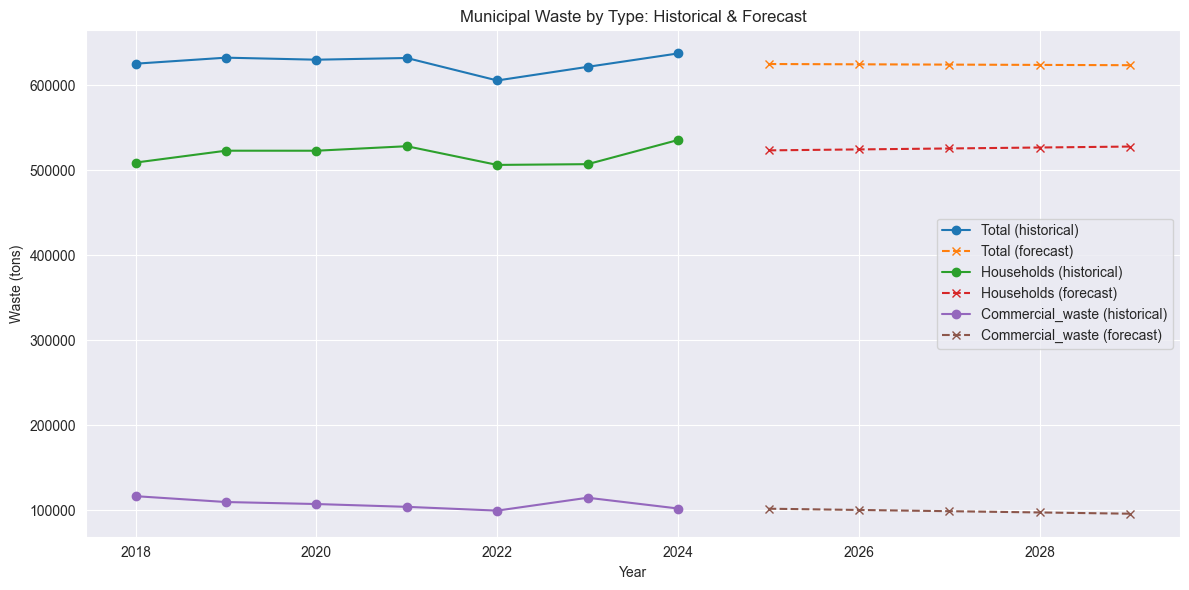

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for col in columns_to_model:
    plt.plot(df["Year"], df[col], marker='o', label=f"{col} (historical)")
    plt.plot(future_years["Year"], df_forecast[col], marker='x', linestyle='--', label=f"{col} (forecast)")

plt.title("Municipal Waste by Type: Historical & Forecast")
plt.xlabel("Year")
plt.ylabel("Waste (tons)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()